In [1]:
# ==========================================================
# E-Waste Image Classification using CNN
# ==========================================================

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
from tensorflow.keras.layers import BatchNormalization

from tensorflow.keras import layers
from tensorflow.keras import models

In [2]:
# ==========================================================
# Dataset Paths
# ==========================================================

train_path = "modified-dataset/train"

valid_path = "modified-dataset/val"

test_path = "modified-dataset/test"

In [3]:
# ==========================================================
# Load Training Dataset
# ==========================================================

train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_path,
    labels="inferred",
    label_mode="int",
    image_size=(150,150),
    batch_size=32,
    shuffle=True
)

# Save class names immediately
class_names = train_dataset.class_names

# ==========================================================
# Load Validation Dataset
# ==========================================================

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    valid_path,
    labels="inferred",
    label_mode="int",
    image_size=(150,150),
    batch_size=32,
    shuffle=False
)

# ==========================================================
# Load Test Dataset
# ==========================================================

test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_path,
    labels="inferred",
    label_mode="int",
    image_size=(150,150),
    batch_size=32,
    shuffle=False
)


# ==========================================================
# Optimize Dataset Performance
# ==========================================================

AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(AUTOTUNE)
validation_dataset = validation_dataset.prefetch(AUTOTUNE)
test_dataset = test_dataset.prefetch(AUTOTUNE)

Found 2400 files belonging to 10 classes.
Found 300 files belonging to 10 classes.
Found 300 files belonging to 10 classes.


In [4]:
# ==========================================================
# Build Improved CNN Model
# ==========================================================

model = tf.keras.Sequential([

    # Input Layer
    tf.keras.Input(shape=(150, 150, 3)),

    # ------------------------------------------------------
    # Data Augmentation
    # ------------------------------------------------------
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.05),
    layers.RandomContrast(0.10),

    # ------------------------------------------------------
    # Normalize Pixel Values
    # ------------------------------------------------------
    layers.Rescaling(1./255),

    # ======================================================
    # Block 1
    # ======================================================
    layers.Conv2D(
        filters=32,
        kernel_size=(3,3),
        activation='relu',
        padding='same'
    ),

    layers.BatchNormalization(),

    layers.MaxPooling2D(pool_size=(2,2)),

    layers.Dropout(0.25),

    # ======================================================
    # Block 2
    # ======================================================
    layers.Conv2D(
        filters=64,
        kernel_size=(3,3),
        activation='relu',
        padding='same'
    ),

    layers.BatchNormalization(),

    layers.MaxPooling2D(pool_size=(2,2)),

    layers.Dropout(0.25),

    # ======================================================
    # Block 3
    # ======================================================
    layers.Conv2D(
        filters=128,
        kernel_size=(3,3),
        activation='relu',
        padding='same'
    ),

    layers.BatchNormalization(),

    layers.MaxPooling2D(pool_size=(2,2)),

    layers.Dropout(0.30),

    # ======================================================
    # Classification Head
    # ======================================================
    layers.GlobalAveragePooling2D(),

    layers.Dense(
        128,
        activation='relu'
    ),

    layers.Dropout(0.40),

    layers.Dense(
        10,
        activation='softmax'
    )

])

In [5]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 150, 150, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast                 │ (None, 150, 150, 3)    │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 37, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,946 (437.29 KB)

 Trainable params: 111,498 (435.54 KB)

 Non-trainable params: 448 (1.75 KB)

In [6]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [8]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)




In [10]:
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=50,
    callbacks=[early_stop]
)

Epoch 1/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 54s 722ms/step - accuracy: 0.3429 - loss: 1.8543 - val_accuracy: 0.1033 - val_loss: 2.9593
Epoch 2/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 64s 851ms/step - accuracy: 0.4004 - loss: 1.7160 - val_accuracy: 0.1267 - val_loss: 3.0187
Epoch 3/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 94s 1s/step - accuracy: 0.4525 - loss: 1.5634 - val_accuracy: 0.1467 - val_loss: 3.8863
Epoch 4/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 77s 1s/step - accuracy: 0.4725 - loss: 1.4690 - val_accuracy: 0.2967 - val_loss: 2.3045
Epoch 5/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 74s 990ms/step - accuracy: 0.4783 - loss: 1.4296 - val_accuracy: 0.2500 - val_loss: 2.8449
Epoch 6/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 74s 988ms/step - accuracy: 0.5379 - loss: 1.3300 - val_accuracy: 0.3267 - val_loss: 2.3259
Epoch 7/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 74s 984ms/step - accuracy: 0.5496 - loss: 1.2652 - val_accuracy: 0.4433 - val_loss: 1.6988
Epoch 8/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 74s 989ms/step - accuracy: 0.5479 - loss: 1.2305 - val_accuracy: 

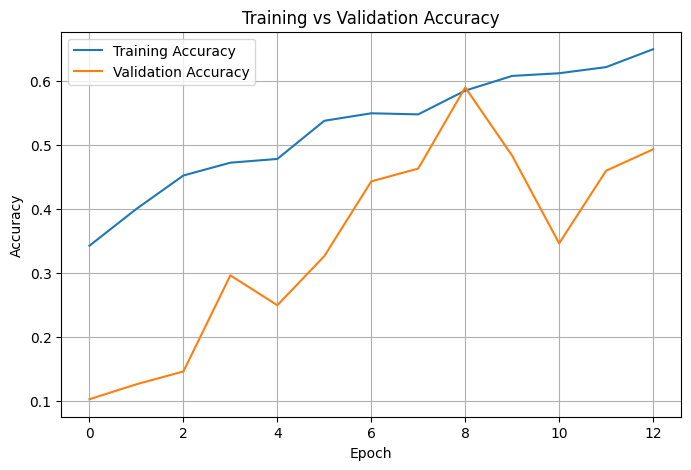

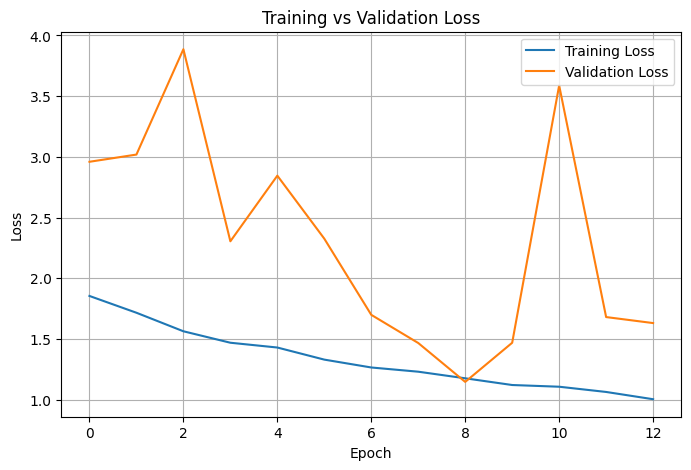

In [11]:
# ==========================================================
# Plot Accuracy and Loss
# ==========================================================

import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# Loss
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [12]:
# ==========================================================
# Evaluate Model on Test Dataset
# ==========================================================

test_loss, test_accuracy = model.evaluate(test_dataset)

print("="*50)
print(f"Test Accuracy : {test_accuracy*100:.2f}%")
print(f"Test Loss     : {test_loss:.4f}")
print("="*50)

10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 169ms/step - accuracy: 0.6133 - loss: 1.1926
Test Accuracy : 61.33%
Test Loss     : 1.1926


In [13]:
class_names = [
    "Battery",
    "Keyboard",
    "Microwave",
    "Mobile",
    "Mouse",
    "PCB",
    "Player",
    "Printer",
    "Television",
    "Washing Machine"
]

In [14]:
# ==========================================================
# Generate Predictions
# ==========================================================

import numpy as np

y_true = []
y_pred = []

for images, labels in test_dataset:

    predictions = model.predict(images, verbose=0)

    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

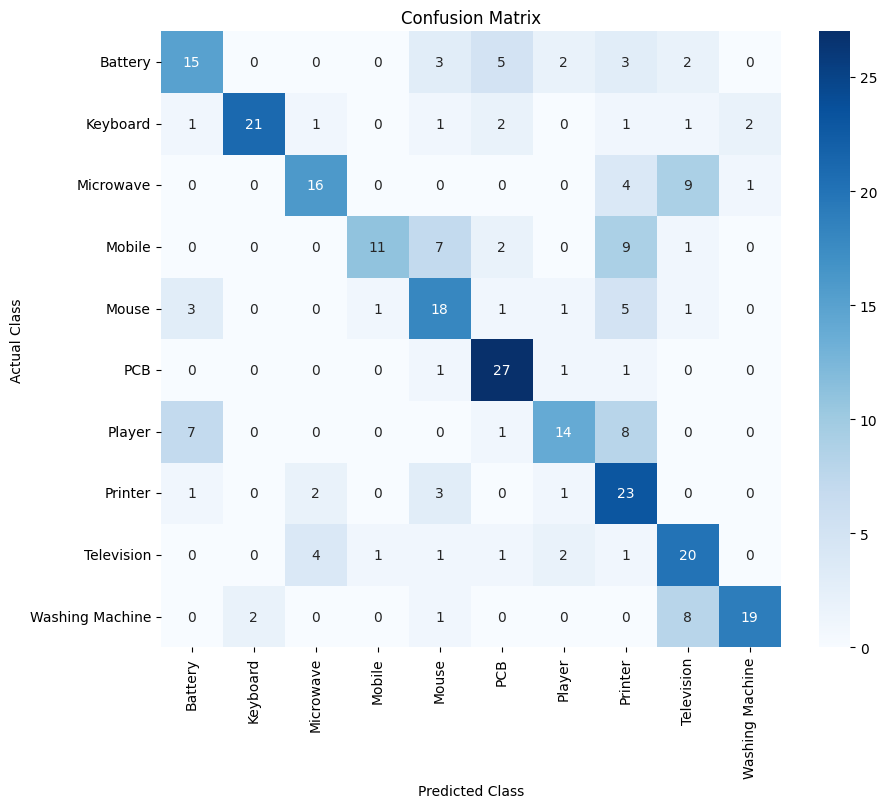

In [15]:
# ==========================================================
# Confusion Matrix
# ==========================================================

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix")

plt.show()

In [16]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
))

                 precision    recall  f1-score   support

        Battery     0.5556    0.5000    0.5263        30
       Keyboard     0.9130    0.7000    0.7925        30
      Microwave     0.6957    0.5333    0.6038        30
         Mobile     0.8462    0.3667    0.5116        30
          Mouse     0.5143    0.6000    0.5538        30
            PCB     0.6923    0.9000    0.7826        30
         Player     0.6667    0.4667    0.5490        30
        Printer     0.4182    0.7667    0.5412        30
     Television     0.4762    0.6667    0.5556        30
Washing Machine     0.8636    0.6333    0.7308        30

       accuracy                         0.6133       300
      macro avg     0.6642    0.6133    0.6147       300
   weighted avg     0.6642    0.6133    0.6147       300



In [17]:
model.save("EWaste_CNN_Model.keras")